
# Importações

In [2]:
import os
import random
import warnings
import locale
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib import dates as mdates

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

from pyESN import ESN
from shap.plots import colors
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from wsb import WSB

locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
MODELOS = ["ESN", "MLP", "RF", "XGBoost"]
MODELOS_WSB = ["WSB-LOCAL", "WSB-GLOBAL"]
SEED = 100
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
HORIZONTES = [3, 6, 12]


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


def calcular_rrmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mean_y_true = np.mean(y_true)

    rrmse = rmse / mean_y_true
    return rrmse


warnings.filterwarnings("ignore")
reset_seed()

C:\Users\eduar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carregar Datasets

In [2]:
df = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

## Normalização

In [3]:
# Repete a normalização para obtermos so scalers correspondentes
scalers = {}
dataframes = []

for campus, dados in df.groupby("CAMPUS"):
    scaler = MinMaxScaler()
    dados[["CONSUMO"]] = scaler.fit_transform(dados[["CONSUMO"]])

    scalers[campus] = scaler
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)

## Criação dos Lags

In [4]:
dataframes = []

for campus, dados in df.sort_values("DATA").groupby("CAMPUS"):
    lags = {f'LAG_{i:02d}': dados['CONSUMO'].shift(i) for i in range(1, 12 + 1)}
    dados = pd.concat([dados, pd.DataFrame(lags)], axis=1)
    dados.dropna(inplace=True)
    dados["ORDEM"] = range(1, len(dados) + 1)
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,LAG_03,LAG_04,LAG_05,LAG_06,LAG_07,LAG_08,LAG_09,LAG_10,LAG_11,LAG_12
0,0.615105,2016-02-29,19,22,25,28,734,33,4,19,...,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886,0.502037
1,0.711047,2016-03-31,12,17,22,28,685,32,3,12,...,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886
2,0.633361,2016-04-30,4,9,23,28,702,33,2,4,...,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078
3,0.406291,2016-05-31,4,11,16,22,490,27,9,4,...,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844
4,0.362467,2016-06-30,-1,7,14,20,408,27,3,-1,...,0.711047,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248,0.743880
2091,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248
2092,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038
2093,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,0.359224,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059


## Melhores Features

In [5]:
df_features = pd.read_csv("./resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns

df_features

Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],


## Melhores Parâmetros

In [6]:
def get_modelo(nome, tipo_treino=None, campus=None):
    if nome == "ESN":
        return ESN(n_inputs=df_features.shape[0],
                   n_outputs=1,
                   n_reservoir=int(best["ESN"]["Reservoirs"]),
                   sparsity=best["ESN"]["Sparsity"],
                   spectral_radius=best["ESN"]["Spectral Radius"],
                   random_state=int(best["ESN"]["SEED"]))

    if nome == "MLP":
        mlp = MLPRegressor(hidden_layer_sizes=(int(best["MLP"]["Hidden Layers"]),),
                           activation=best["MLP"]["Activation"],
                           alpha=best["MLP"]["Alpha"],
                           random_state=int(best["MLP"]["SEED"]))
        return mlp

    if nome == "RF":
        return RandomForestRegressor(random_state=int(best["RF"]["SEED"]),
                                     n_estimators=int(best["RF"]["N_estimators"]),
                                     max_depth=int(best["RF"]["Max_depth"]),
                                     min_samples_split=int(best["RF"]["Min_samples_split"]),
                                     min_samples_leaf=int(best["RF"]["Min_samples_leaf"]))

    if nome == "XGBoost":
        return XGBRegressor(random_state=int(best["XGBoost"]["SEED"]),
                            n_estimators=int(best["XGBoost"]["N_estimators"]),
                            max_depth=int(best["XGBoost"]["Max_depth"]),
                            booster=best["XGBoost"]["Booster"],
                            reg_lambda=best["XGBoost"]["Lambda"],
                            reg_alpha=best["XGBoost"]["Alpha"],
                            updater="coord_descent" if best["XGBoost"]["Booster"] == "gblinear" else None)

    if nome == "WSB-LOCAL" or nome == "WSB-GLOBAL":
        strong_pred = best[f"WSB-{tipo_treino}-{campus}"]["Strong_predictor"]
        return WSB(strong_predictor=get_modelo(strong_pred),
                   weak_predictors=[get_modelo(m) for m in MODELOS if m != strong_pred],
                   weight_g=best[f"WSB-{tipo_treino}-{campus}"]["Weight_g"])


best = {}
for modelo in MODELOS:
    df_aux = pd.read_csv(
        f"./resultados/otimização - regressão/BEST-{modelo}.csv", sep=';',
        decimal='.', header=0)
    display(df_aux)
    best[modelo] = df_aux.iloc[0]

for modelo in MODELOS_WSB:
    dfs_wsb = []
    for campus in df["CAMPUS"].unique():
        df_aux = pd.read_csv(
            f"./resultados/otimização - regressão/COA-{modelo}/BEST-{modelo}-{campus}.csv", sep=';',
            decimal='.', header=0)
        dfs_wsb.append(df_aux)
        best[f"{modelo}-{campus}"] = df_aux.iloc[0]

    dfs_wsb = pd.concat(dfs_wsb, ignore_index=True)
    display(dfs_wsb)

,OTIMIZADOR,MODELO,SEED,Reservoirs,Sparsity,Spectral Radius,Fitness
0,PSO,ESN,9000,11.0,0.23,0.639,0.289


,OTIMIZADOR,MODELO,SEED,Hidden Layers,Alpha,Activation,Fitness
0,PSO,MLP,10000,220,0.979,relu,0.227


,OTIMIZADOR,MODELO,SEED,N_estimators,Max_depth,Min_samples_split,Min_samples_leaf,Fitness
0,PSO,RF,7000,15.0,232.0,11.0,4.0,0.247


,OTIMIZADOR,MODELO,SEED,N_estimators,Max_depth,Booster,Lambda,Alpha,Fitness
0,PSO,XGBoost,5000,242,119,gbtree,0.898,0.041,0.243


,OTIMIZADOR,MODELO,SEED,Strong_predictor,Weight_g,Fitness
0,COA,WSB-LOCAL-ASSIS CHATEAUBRIAND,6000,XGBoost,-1.000,0.333
1,COA,WSB-LOCAL-ASTORGA,6000,XGBoost,-1.000,0.374
2,COA,WSB-LOCAL-BARRACÃO,3000,XGBoost,-0.994,0.357
3,COA,WSB-LOCAL-CAMPO LARGO,1000,XGBoost,-0.892,0.183
4,COA,WSB-LOCAL-CAPANEMA,10000,XGBoost,-0.989,0.297
5,COA,WSB-LOCAL-CASCAVEL,10000,XGBoost,-0.989,0.306
6,COA,WSB-LOCAL-CORONEL VIVIDA,1000,XGBoost,-0.399,0.397
7,COA,WSB-LOCAL-CURITIBA,1000,XGBoost,-0.982,0.615
8,COA,WSB-LOCAL-FOZ DO IGUAÇU,10000,XGBoost,-0.989,0.375
9,COA,WSB-LOCAL-GOIOERÊ,10000,XGBoost,-0.989,0.382


,OTIMIZADOR,MODELO,SEED,Strong_predictor,Weight_g,Fitness
0,COA,WSB-GLOBAL-ASSIS CHATEAUBRIAND,10000,ESN,-0.003,0.289
1,COA,WSB-GLOBAL-ASTORGA,6000,ESN,-1.000,0.287
2,COA,WSB-GLOBAL-BARRACÃO,10000,ESN,-0.989,0.297
3,COA,WSB-GLOBAL-CAMPO LARGO,10000,ESN,-0.989,0.321
4,COA,WSB-GLOBAL-CAPANEMA,10000,ESN,-0.003,0.255
5,COA,WSB-GLOBAL-CASCAVEL,1000,ESN,-0.990,0.270
6,COA,WSB-GLOBAL-CORONEL VIVIDA,1000,ESN,-0.990,0.234
7,COA,WSB-GLOBAL-CURITIBA,1000,ESN,-0.797,0.684
8,COA,WSB-GLOBAL-FOZ DO IGUAÇU,1000,ESN,-0.990,0.316
9,COA,WSB-GLOBAL-GOIOERÊ,1000,ESN,-0.531,0.275


# Divisão dos Dados


In [7]:
dfs_treino = {}
dfs_teste = {}
for horizonte in HORIZONTES:
    treino = []
    teste = []

    for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
        dados["CAMPUS"] = campus

        dados_treino, dados_teste = train_test_split(dados, test_size=horizonte, shuffle=False)

        treino.append(dados_treino)
        teste.append(dados_teste)

    treino = pd.DataFrame(pd.concat(treino, ignore_index=True))
    teste = pd.DataFrame(pd.concat(teste, ignore_index=True))

    dfs_treino[horizonte] = treino
    dfs_teste[horizonte] = teste



# Execução dos Experimentos

In [8]:
def treino(previsor, dados_treino, features):
    x_treino = dados_treino[features].to_numpy()
    y_treino = dados_treino["CONSUMO"].to_numpy()

    previsor.fit(x_treino, y_treino)
    return previsor


def teste(previsor, historico_campus, x_teste, features, horizonte):
    historico = historico_campus[["CONSUMO"]].copy()
    x_teste = x_teste[features].copy()

    previsoes = []

    for i_test in range(horizonte):
        row = x_teste.iloc[[i_test]].copy()
        historico = pd.concat([historico, pd.DataFrame([0], columns=["CONSUMO"], index=[i_test])], axis=0)

        # Recalcula os lags conforme os valores previstos pelo modelo
        lags = pd.DataFrame({f'LAG_{i:02d}': historico["CONSUMO"].shift(i) for i in range(1, 12 + 1) if
                             f'LAG_{i:02d}' in features}).tail(1)
        row.update(lags)

        if isinstance(previsor, WSB):
            peso_t = 1
            if horizonte > 3:
                peso_t = i_test / horizonte
            prev = previsor.predict(row.to_numpy(), peso_t)[0]
        elif isinstance(previsor, ESN):
            prev = previsor.predict(row.to_numpy())[0][0]
        else:
            prev = previsor.predict(row.to_numpy())[0]

        row["CONSUMO"] = prev
        previsoes.append(prev)
        historico.update(row)

    return pd.DataFrame({"CONSUMO PREVISTO": previsoes}, index=x_teste.index)



## Treinamento Local

In [9]:
for horizonte in HORIZONTES:
    df_treino = dfs_treino[horizonte]
    for campus, dados_teste in dfs_teste[horizonte].sort_values("DATA").groupby("CAMPUS"):
        dados_teste = dados_teste.set_index('DATA')
        df_previsoes = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != f"WSB-GLOBAL"],
                                    index=dados_teste.index)

        for nome_modelo in df_previsoes.columns:
            # Treina o modelo com os dados do campus atual
            dados_treino = df_treino[df_treino["CAMPUS"] == campus]
            modelo = treino(get_modelo(nome_modelo, "LOCAL", campus), dados_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, dados_treino, dados_teste, df_features, horizonte)
            df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

        os.makedirs(f"resultados/regressão - local/{horizonte} meses", exist_ok=True)
        df_previsoes.to_csv(
            f"resultados/regressão - local/{horizonte} meses/PREVISÕES REGRESSÃO - LOCAL {horizonte}M - {campus}.csv",
            sep=";", decimal=".", header=True,
            index=True)


## Treinamento Global

In [10]:

for horizonte in HORIZONTES:
    df_treino = dfs_treino[horizonte]
    for campus, dados_teste in dfs_teste[horizonte].sort_values("DATA").groupby("CAMPUS"):
        dados_teste = dados_teste.set_index('DATA')
        df_previsoes = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != f"WSB-LOCAL"],
                                    index=dados_teste.index)

        for nome_modelo in df_previsoes.columns:
            # Treina o modelo com os dados de todos os campi
            modelo = treino(get_modelo(nome_modelo, "GLOBAL", campus), df_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, df_treino[df_treino["CAMPUS"] == campus], dados_teste, df_features, horizonte)
            df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

        os.makedirs(f"resultados/regressão - global/{horizonte} meses", exist_ok=True)
        df_previsoes.to_csv(
            f"resultados/regressão - global/{horizonte} meses/PREVISÕES REGRESSÃO - GLOBAL {horizonte}M - {campus}.csv",
            sep=";", decimal=".",
            index=True)



# Análise dos Resultados

In [31]:
def formatar_y(valor, pos):
    if valor >= 100:
        return f"100+"
    return int(valor)


def ts_comparacao(campus, valor_real, valores_previstos, erros, horizonte):
    valor_real = valor_real.tail(horizonte)
    plt.figure(figsize=(10, 4) if horizonte > 6 else (6, 3.5))
    plt.rcParams['xtick.labelsize'] = 17
    plt.rcParams['ytick.labelsize'] = 17
    plt.rcParams.update({'font.size': 14})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["#2E8B57", "blue", "#B8860B", colors.red_rgb, "#4B0082"])

    for nome_modelo in valores_previstos.columns:
        plt.plot(valores_previstos[nome_modelo],
                 label=f"{"COA-WSB" if "WSB-" in nome_modelo else nome_modelo}", linewidth=3)

    plt.plot(valor_real["CONSUMO"], label=f"REAL", color="black", linewidth=3, linestyle="--")

    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white', framealpha=0.5)

    plt.title(f"CAMPUS {campus}")
    plt.xlabel('Mês')
    plt.ylabel('Consumo (KWh)')

    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_xticks(valores_previstos.index if horizonte < 6 else valores_previstos.index[::2])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b./%y'))
    legend = ax.get_legend()
    legend.set_visible(False)

    return ax, plt


def ts_comparacao_horizonte(erro, nome_medida):
    plt.figure(figsize=(6, 4.5))
    plt.rcParams['xtick.labelsize'] = 17
    plt.rcParams['ytick.labelsize'] = 17
    plt.rcParams.update({'font.size': 14})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["#2E8B57", "blue", "#FBC02D", colors.red_rgb, "#4B0082"])

    bar_width = 0.18  # Largura de cada barra
    x_positions = np.arange(len(HORIZONTES))

    for i, nome_modelo in enumerate(erro.columns):
        bars = plt.bar(x_positions + i * bar_width, erro[nome_modelo] * 100, bar_width,
                       label=f"{"COA-WSB" if "WSB-" in nome_modelo else nome_modelo}")

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 1 if height < 93 else 94, f"{int(height)}",
                     ha='center', va='bottom', color='black' if height < 93 else 'white', size=11)

    plt.xlabel('Horizonte (Meses)')
    plt.ylabel(f'{nome_medida} Médio (%)')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_y))

    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_ylim(0, 100)
    ax.set_xticks(x_positions + bar_width * (len(MODELOS) - 1) / 2)
    ax.set_xticklabels(HORIZONTES)
    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt


def medidas_desempenho(valor_real, valores_previstos, horizonte):
    df_desempenho = pd.DataFrame(columns=["MAPE", "RRMSE"], index=valores_previstos.columns)

    for nome_modelo in valores_previstos.columns:
        df_desempenho.loc[nome_modelo] = [
            np.round(mape(valor_real["CONSUMO"].tail(horizonte), valores_previstos[nome_modelo].tail(horizonte)), 3),
            np.round(
                calcular_rrmse(valor_real["CONSUMO"].tail(horizonte), valores_previstos[nome_modelo].tail(horizonte)),
                3),
        ]

    return df_desempenho


## Treinamento Local
### Cálculo das Medidas de Desempenho

In [32]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

for horizonte in HORIZONTES:
    df_RRMSE = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                            index=df_real["CAMPUS"].unique())
    df_MAPE = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                           index=df_real["CAMPUS"].unique())

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - local/{horizonte} meses/PREVISÕES REGRESSÃO - LOCAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_RRMSE.loc[campus] = df_desempenho["RRMSE"]
        df_MAPE.loc[campus] = df_desempenho["MAPE"]

        ax, plt = ts_comparacao(campus, dados, consumo_previsto, df_desempenho, horizonte)

        df_desempenho.to_csv(
            f"resultados/regressão - local/{horizonte} meses/RRMSE REGRESSÃO - LOCAL {horizonte}M {campus}.csv",
            sep=";", decimal=".", index=True)
        plt.savefig(
            f"resultados/regressão - local/{horizonte} meses/PREVISÕES REGRESSÃO - LOCAL {horizonte}M {campus}.png",
            bbox_inches='tight')
        plt.close()

        handles, labels = ax.get_legend_handles_labels()
        fig_legend = plt.figure(figsize=(12, 0.5))
        leg = fig_legend.legend(handles, labels, loc='center', frameon=False, ncol=len(df_MAPE.columns) + 1)
        plt.axis('off')
        fig_legend.savefig(f"resultados/regressão - local/{horizonte} meses/LEGENDAS.png", bbox_inches='tight',
                           pad_inches=0.05, transparent=True)
        plt.close(fig_legend)

    df_RRMSE = df_RRMSE.add_suffix(" RRMSE")
    df_MAPE = df_MAPE.add_suffix(" MAPE")

    pior_RRMSE = (df_RRMSE.eq(df_RRMSE.max(axis=1), axis=0).sum(axis=0))
    melhor_RRMSE = (df_RRMSE.eq(df_RRMSE.min(axis=1), axis=0).sum(axis=0))

    pior_MAPE = (df_MAPE.eq(df_MAPE.max(axis=1), axis=0).sum(axis=0))
    melhor_MAPE = (df_MAPE.eq(df_MAPE.min(axis=1), axis=0).sum(axis=0))

    df_medias = pd.concat([df_RRMSE, df_MAPE], axis=1)
    df_medias.loc["MÉDIAS"] = df_medias.mean()

    df_medias.loc["MELHOR"] = pd.concat([melhor_RRMSE, melhor_MAPE], axis=0)
    df_medias.loc["PIOR"] = pd.concat([pior_RRMSE, pior_MAPE], axis=0)
    df_medias.loc["SCORE (MELHOR - PIOR)"] = pd.concat([melhor_RRMSE - pior_RRMSE, melhor_MAPE - pior_MAPE], axis=0)

    df_medias.to_csv(f"resultados/regressão - local/MÉDIAS ERROS REGRESSÃO - LOCAL {horizonte}M.csv", sep=";",
                     decimal=".", index=True)
    display(df_medias)



,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-LOCAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-LOCAL MAPE
ASSIS CHATEAUBRIAND,0.311,0.124,0.297,0.385,0.354,0.259,0.064,0.22,0.289,0.263
ASTORGA,0.327,0.279,0.299,0.335,0.314,0.272,0.274,0.275,0.292,0.28
BARRACÃO,0.11,0.16,0.136,0.272,0.239,0.097,0.159,0.136,0.27,0.237
CAMPO LARGO,0.314,0.287,0.174,0.306,0.292,0.275,0.285,0.17,0.297,0.282
CAPANEMA,0.423,0.204,0.23,0.166,0.178,0.315,0.103,0.171,0.137,0.135
CASCAVEL,0.283,0.179,0.245,0.266,0.261,0.253,0.161,0.177,0.203,0.197
CORONEL VIVIDA,0.293,0.239,0.198,0.219,0.215,0.224,0.231,0.168,0.202,0.2
CURITIBA,0.963,0.22,0.168,0.262,0.204,0.902,0.133,0.166,0.246,0.17
FOZ DO IGUAÇU,0.222,0.285,0.118,0.211,0.206,0.201,0.247,0.113,0.203,0.183
GOIOERÊ,0.306,0.182,0.113,0.282,0.18,0.289,0.146,0.099,0.199,0.145


,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-LOCAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-LOCAL MAPE
ASSIS CHATEAUBRIAND,0.328,0.524,0.421,0.422,0.373,0.25,0.757,0.511,0.48,0.466
ASTORGA,0.308,0.284,0.288,0.301,0.247,0.222,0.267,0.242,0.223,0.199
BARRACÃO,0.25,0.21,0.199,0.242,0.212,0.208,0.21,0.182,0.222,0.195
CAMPO LARGO,0.468,0.426,0.364,0.388,0.357,0.601,0.543,0.402,0.46,0.446
CAPANEMA,0.509,0.451,0.402,0.338,0.349,0.505,0.623,0.503,0.412,0.409
CASCAVEL,0.472,0.42,0.365,0.329,0.32,0.591,0.466,0.381,0.382,0.368
CORONEL VIVIDA,0.245,0.278,0.217,0.206,0.2,0.207,0.283,0.168,0.152,0.15
CURITIBA,0.591,0.343,0.312,0.289,0.22,0.298,0.344,0.338,0.29,0.239
FOZ DO IGUAÇU,0.451,0.431,0.432,0.339,0.348,0.422,0.416,0.435,0.33,0.303
GOIOERÊ,0.469,0.514,0.35,0.539,0.518,0.447,0.543,0.346,0.478,0.471


,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-LOCAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-LOCAL MAPE
ASSIS CHATEAUBRIAND,0.281,0.398,0.361,0.345,0.347,0.178,0.552,0.42,0.414,0.426
ASTORGA,0.477,0.308,0.307,0.335,0.318,0.431,0.237,0.229,0.255,0.238
BARRACÃO,0.289,0.23,0.295,0.28,0.273,0.234,0.218,0.268,0.243,0.241
CAMPO LARGO,0.366,0.335,0.336,0.326,0.31,0.359,0.379,0.356,0.321,0.336
CAPANEMA,0.535,0.431,0.396,0.341,0.382,0.471,0.551,0.437,0.365,0.43
CASCAVEL,0.274,0.299,0.326,0.283,0.269,0.284,0.286,0.328,0.257,0.256
CORONEL VIVIDA,0.345,0.344,0.268,0.239,0.245,0.304,0.379,0.288,0.25,0.259
CURITIBA,0.842,0.393,0.296,0.355,0.297,0.668,0.251,0.265,0.309,0.24
FOZ DO IGUAÇU,0.385,0.513,0.438,0.485,0.479,0.423,0.567,0.51,0.519,0.516
GOIOERÊ,0.255,0.267,0.304,0.278,0.266,0.273,0.298,0.276,0.281,0.273


### Evolução do RRMSE com o Horizonte

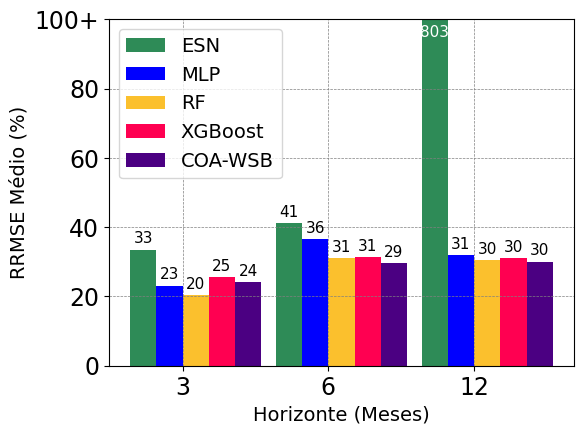

In [33]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df_mape_todos = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                             index=pd.Index(HORIZONTES, name="HORIZONTES"))

for horizonte in HORIZONTES:
    df_rrmse = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                            index=df_real["CAMPUS"].unique())
    rrmse_horizontes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - local/{horizonte} meses/PREVISÕES REGRESSÃO - LOCAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_rrmse.loc[campus] = df_desempenho["RRMSE"]
        rrmse_horizontes.append(df_desempenho["RRMSE"])

    if rrmse_horizontes:
        df_mape_todos.loc[horizonte] = pd.concat(rrmse_horizontes, axis=1).mean(axis=1)

plt = ts_comparacao_horizonte(df_mape_todos, "RRMSE")
plt.savefig(f"resultados/regressão - local/RRMSE MÉDIO REGRESSÃO - LOCAL.png", bbox_inches='tight')
plt.show()

### Evolução do MAPE com o Horizonte

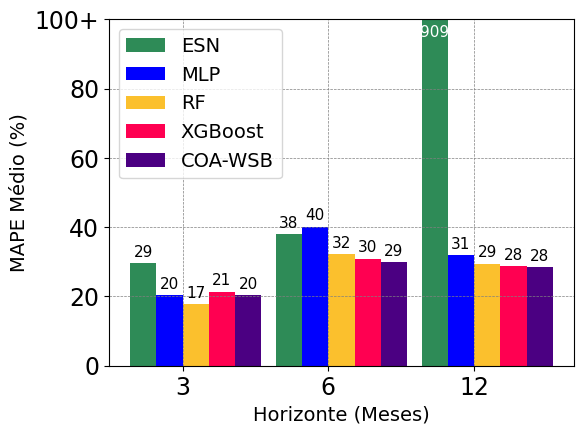

In [34]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df_mape_todos = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                             index=pd.Index(HORIZONTES, name="HORIZONTES"))

for horizonte in HORIZONTES:
    df_rrmse = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-GLOBAL"],
                            index=df_real["CAMPUS"].unique())
    rrmse_horizontes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - local/{horizonte} meses/PREVISÕES REGRESSÃO - LOCAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_rrmse.loc[campus] = df_desempenho["MAPE"]
        rrmse_horizontes.append(df_desempenho["MAPE"])

    if rrmse_horizontes:
        df_mape_todos.loc[horizonte] = pd.concat(rrmse_horizontes, axis=1).mean(axis=1)

plt = ts_comparacao_horizonte(df_mape_todos, "MAPE")
plt.savefig(f"resultados/regressão - local/MAPE MÉDIO REGRESSÃO - LOCAL.png", bbox_inches='tight')
plt.show()

## Treinamento Global
### Cálculo das Medidas de Desempenho

In [35]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

for horizonte in HORIZONTES:

    df_RRMSE = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                            index=df_real["CAMPUS"].unique())
    df_MAPE = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                           index=df_real["CAMPUS"].unique())

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - global/{horizonte} meses/PREVISÕES REGRESSÃO - GLOBAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_RRMSE.loc[campus] = df_desempenho["RRMSE"]
        df_MAPE.loc[campus] = df_desempenho["MAPE"]

        ax, plt = ts_comparacao(campus, dados, consumo_previsto, df_desempenho, horizonte)

        df_desempenho.to_csv(
            f"resultados/regressão - global/{horizonte} meses/RRMSE REGRESSÃO - GLOBAL {horizonte}M {campus}.csv",
            sep=";", decimal=".", index=True)
        plt.savefig(
            f"resultados/regressão - global/{horizonte} meses/PREVISÕES REGRESSÃO - GLOBAL {horizonte}M {campus}.png",
            bbox_inches='tight')
        plt.close()

    df_RRMSE = df_RRMSE.add_suffix(" RRMSE")
    df_MAPE = df_MAPE.add_suffix(" MAPE")

    pior_RRMSE = (df_RRMSE.eq(df_RRMSE.max(axis=1), axis=0).sum(axis=0))
    melhor_RRMSE = (df_RRMSE.eq(df_RRMSE.min(axis=1), axis=0).sum(axis=0))

    pior_MAPE = (df_MAPE.eq(df_MAPE.max(axis=1), axis=0).sum(axis=0))
    melhor_MAPE = (df_MAPE.eq(df_MAPE.min(axis=1), axis=0).sum(axis=0))

    df_medias = pd.concat([df_RRMSE, df_MAPE], axis=1)
    df_medias.loc["MÉDIAS"] = df_medias.mean()

    df_medias.loc["MELHOR"] = pd.concat([melhor_RRMSE, melhor_MAPE], axis=0)
    df_medias.loc["PIOR"] = pd.concat([pior_RRMSE, pior_MAPE], axis=0)
    df_medias.loc["SCORE (MELHOR - PIOR)"] = pd.concat([melhor_RRMSE - pior_RRMSE, melhor_MAPE - pior_MAPE], axis=0)

    df_medias.to_csv(f"resultados/regressão - global/MÉDIAS ERROS {horizonte}M.csv", sep=";", decimal=".", index=True)
    display(df_medias)



,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-GLOBAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-GLOBAL MAPE
ASSIS CHATEAUBRIAND,0.335,0.52,0.242,0.31,0.335,0.321,0.415,0.204,0.211,0.321
ASTORGA,0.24,0.4,0.184,0.116,0.225,0.219,0.389,0.176,0.093,0.209
BARRACÃO,0.143,0.255,0.15,0.168,0.14,0.126,0.248,0.139,0.155,0.119
CAMPO LARGO,0.215,0.346,0.247,0.248,0.223,0.184,0.342,0.22,0.245,0.203
CAPANEMA,0.345,0.485,0.292,0.279,0.345,0.332,0.382,0.261,0.177,0.332
CASCAVEL,0.233,0.37,0.214,0.255,0.231,0.169,0.344,0.188,0.232,0.18
CORONEL VIVIDA,0.202,0.298,0.203,0.222,0.201,0.17,0.275,0.179,0.196,0.162
CURITIBA,0.322,0.305,0.057,0.115,0.24,0.306,0.298,0.053,0.108,0.226
FOZ DO IGUAÇU,0.237,0.252,0.112,0.09,0.202,0.225,0.236,0.103,0.075,0.194
GOIOERÊ,0.466,0.143,0.186,0.263,0.426,0.438,0.141,0.193,0.263,0.395


,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-GLOBAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-GLOBAL MAPE
ASSIS CHATEAUBRIAND,0.456,0.564,0.532,0.409,0.455,0.48,0.772,0.745,0.542,0.48
ASTORGA,0.228,0.193,0.194,0.127,0.177,0.188,0.184,0.169,0.117,0.147
BARRACÃO,0.22,0.202,0.238,0.18,0.2,0.182,0.188,0.194,0.153,0.167
CAMPO LARGO,0.276,0.348,0.316,0.359,0.269,0.319,0.448,0.403,0.445,0.323
CAPANEMA,0.409,0.517,0.467,0.453,0.409,0.49,0.678,0.648,0.584,0.49
CASCAVEL,0.291,0.356,0.333,0.379,0.269,0.295,0.403,0.406,0.43,0.299
CORONEL VIVIDA,0.23,0.215,0.257,0.224,0.215,0.18,0.219,0.204,0.169,0.169
CURITIBA,0.287,0.546,0.212,0.258,0.251,0.263,0.633,0.217,0.281,0.242
FOZ DO IGUAÇU,0.256,0.627,0.349,0.318,0.236,0.23,0.632,0.307,0.259,0.212
GOIOERÊ,0.446,0.655,0.525,0.537,0.452,0.357,0.678,0.507,0.502,0.382


,ESN RRMSE,MLP RRMSE,RF RRMSE,XGBoost RRMSE,WSB-GLOBAL RRMSE,ESN MAPE,MLP MAPE,RF MAPE,XGBoost MAPE,WSB-GLOBAL MAPE
ASSIS CHATEAUBRIAND,0.383,0.507,0.385,0.343,0.383,0.369,0.697,0.496,0.438,0.369
ASTORGA,0.246,0.247,0.211,0.195,0.197,0.212,0.233,0.181,0.152,0.17
BARRACÃO,0.174,0.139,0.21,0.192,0.154,0.129,0.121,0.185,0.169,0.128
CAMPO LARGO,0.268,0.405,0.294,0.317,0.292,0.296,0.491,0.333,0.343,0.333
CAPANEMA,0.353,0.539,0.41,0.43,0.353,0.352,0.676,0.461,0.497,0.352
CASCAVEL,0.261,0.333,0.261,0.275,0.26,0.245,0.371,0.297,0.295,0.281
CORONEL VIVIDA,0.279,0.336,0.299,0.269,0.267,0.247,0.391,0.26,0.239,0.247
CURITIBA,0.259,0.395,0.299,0.32,0.263,0.227,0.413,0.305,0.25,0.234
FOZ DO IGUAÇU,0.404,0.691,0.44,0.409,0.41,0.415,0.805,0.423,0.36,0.404
GOIOERÊ,0.267,0.357,0.285,0.27,0.269,0.25,0.424,0.308,0.278,0.26


### Evolução do RRMSE com o Horizonte

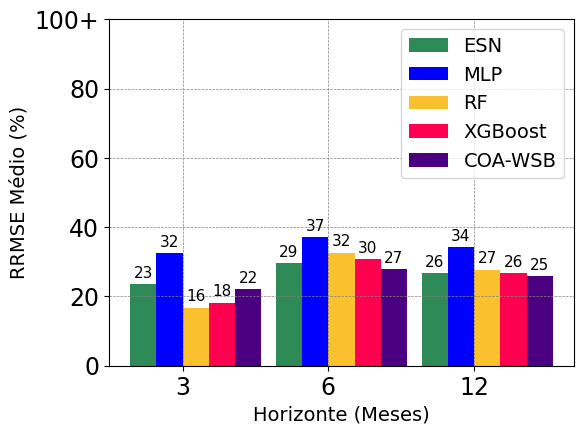

In [36]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df_mape_todos = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                             index=pd.Index(HORIZONTES, name="HORIZONTES"))

for horizonte in HORIZONTES:
    df_rrmse = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                            index=df_real["CAMPUS"].unique())
    rrmse_horizontes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - global/{horizonte} meses/PREVISÕES REGRESSÃO - GLOBAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_rrmse.loc[campus] = df_desempenho["RRMSE"]
        rrmse_horizontes.append(df_desempenho["RRMSE"])

    if rrmse_horizontes:
        df_mape_todos.loc[horizonte] = pd.concat(rrmse_horizontes, axis=1).mean(axis=1)

plt = ts_comparacao_horizonte(df_mape_todos, "RRMSE")
plt.savefig(f"resultados/regressão - global/RRMSE MÉDIO REGRESSÃO - GLOBAL.png", bbox_inches='tight')
plt.show()

### Evolução do MAPE com o Horizonte

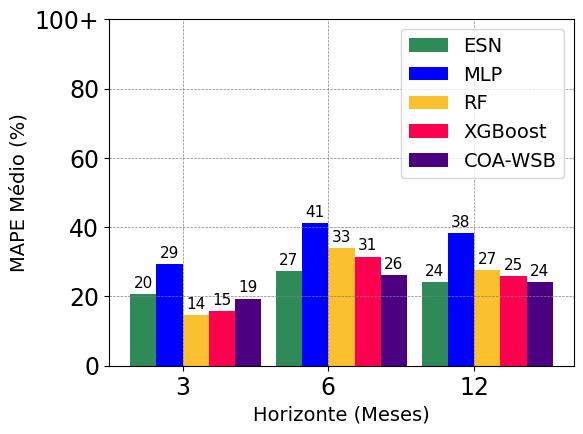

In [37]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df_mape_todos = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                             index=pd.Index(HORIZONTES, name="HORIZONTES"))

for horizonte in HORIZONTES:
    df_rrmse = pd.DataFrame(columns=[m for m in MODELOS + MODELOS_WSB if m != "WSB-LOCAL"],
                            index=df_real["CAMPUS"].unique())
    rrmse_horizontes = []

    for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
        try:
            consumo_previsto = pd.read_csv(
                f"resultados/regressão - global/{horizonte} meses/PREVISÕES REGRESSÃO - GLOBAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".", header=0)
        except Exception as e:
            continue

        consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
        consumo_previsto = consumo_previsto.set_index("DATA")

        dados["DATA"] = pd.to_datetime(dados["DATA"])
        dados = dados.set_index("DATA")

        df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
        df_rrmse.loc[campus] = df_desempenho["MAPE"]
        rrmse_horizontes.append(df_desempenho["MAPE"])

    if rrmse_horizontes:
        df_mape_todos.loc[horizonte] = pd.concat(rrmse_horizontes, axis=1).mean(axis=1)

plt = ts_comparacao_horizonte(df_mape_todos, "MAPE")
plt.savefig(f"resultados/regressão - global/MAPE MÉDIO REGRESSÃO - GLOBAL.png", bbox_inches='tight')
plt.show()